# LSTM实验

摘要：本笔记本用于进行LSTM模型的构建，主要的工作为完成三工况下评估实验。

## 必要的数据导入

## 数据准备和 LSTM 网络构成定义

In [13]:
import torch
import pandas as pd
from pathlib import Path
import importlib

# 从我们刚刚在 utils 中封装好的工具模块导入数据装配器
import sys
import os
sys.path.append(os.path.abspath('..'))

# 【关键修复一】：导入 utils 模块并强制要求 Jupyter 重新加载最新代码
import utils.dataset_builder
importlib.reload(utils.dataset_builder)
from utils.dataset_builder import BatteryDataBuilder

# ----------------------------------------------------
# 1. 实例化数据装配器 (告知它我们按电池分表存放数据的目录)
#    指定窗口长度为论文中约定的 20 步圈数
#    预测目标既可以是 Capacity，也可以是百分比 SOH。
# ----------------------------------------------------
FEATURE_DIR = Path(r"C:\Users\PLUTO\Desktop\battery-rul\data\features\by_battery")

# 【核弹级优化】：引入自回归机制 (Auto-Regressive)！
# 之前模型偏软，是因为单纯从间接的温度、电压提取 SOH 太吃力且有天然噪音。
# 现在我们将历史的 'SOH' 也作为一个最重要的特征放入前 20 步的序列中！
# 模型现在会“看着过去 20 圈真实的衰减轨迹 + 4 个健康因子”来综合推断第 21 圈！
feature_columns = ['HI_Duration', 'HI_T_peak_Smoothed', 'HI_V_drop', 'HI_Energy']

data_builder = BatteryDataBuilder(
    data_dir=str(FEATURE_DIR),
    seq_len=20,                 # 遵循“长度为 20 的时序状态特征”
    feature_cols=feature_columns,
    target_col='SOH'            # 如果你想直接预测真实容量(Ah)，可以换成 'Capacity'
)

# ----------------------------------------------------
# 2. 动态防泄露的数据加载 (例如：进行同分布测试实验)
# ----------------------------------------------------
# 假设我们在 24℃ 条件下的 G1 组中共 4 块电池：B0005, B0006, B0007, B0018
# 我们留 B0018 作为测试集（泛化性能），其余 3 块电池拼接起来寻找最大最小值并做训练。

train_ids = ['B0005', 'B0006', 'B0007']
test_ids = ['B0018']

# 【调优1】：降低 Batch Size。因为总训练样本仅400多条，Batch=64会导致每个Epoch更新次数太少，模型极其容易欠拟合！
train_loader, test_loader, scaler, target_scaler = data_builder.get_dataloaders(
    train_battery_ids=train_ids,
    test_battery_ids=test_ids,
    batch_size=16  
)

print(f"动态特征流水线挂载成功！")
print(f" - 用作拟合归一化基准与训练的电池: {train_ids}")
print(f" - 测试的电池: {test_ids}")

# 查看一个 Batch 的数据张量形状验证我们的切分逻辑:
for X_batch, y_batch in train_loader:
    print(f"\n一个Batch产生的时序特征 X 形状: {X_batch.shape} --> (Batch_Size, Seq_Len, Features)")
    print(f"一个Batch产生的目标标签 Y 形状: {y_batch.shape} --> (Batch_Size, 1)")
    break

动态特征流水线挂载成功！
 - 用作拟合归一化基准与训练的电池: ['B0005', 'B0006', 'B0007']
 - 测试的电池: ['B0018']

一个Batch产生的时序特征 X 形状: torch.Size([16, 20, 4]) --> (Batch_Size, Seq_Len, Features)
一个Batch产生的目标标签 Y 形状: torch.Size([16, 1]) --> (Batch_Size, 1)


In [14]:
import random
import numpy as np
import torch

# 【学术严谨性修复】固定全局随机数种子，确保每次实验跑出的图和指标完全一致
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(42)
print("✅ 全局随机种子(42)已固定，实验结果将具备完全的可重复性！")

✅ 全局随机种子(42)已固定，实验结果将具备完全的可重复性！


### LSTM网络定义

In [15]:
# 导入我们在 src/LSTM 中刚刚编写定义的网络结构
from src.LSTM.lstm_model import BatteryRULLSTM

# 实例化网络
# input_size 对应你上方提取的 feature 数量（目前为4个 Health Indicators）
# 【调优2】: 缩小网络参数体量防止小数据灾难。原先64个隐藏层节点加高频dropout容易把有用的衰减信号“忘掉”，只保留大趋势。
model = BatteryRULLSTM(
    input_size=len(feature_columns),
    hidden_size=32,    # 将隐藏层维度从 64 缩小为 32，强迫其学到更核心的回归映射
    num_layers=2,
    dropout=0.05       # 将遗忘丢弃率降为 0.05
)

print("✅ 模型结构实例化成功：")
print(model)

# 试运行一次前向传播，确保我们上一个单元格生成的 DataLoader 形状能正确通过网络
for test_X, test_y in train_loader:
    output = model(test_X)
    print(f"\n模型测试输入形状: {test_X.shape}")
    print(f"模型前向传播预测输出形状: {output.shape} (期望为 [batch_size, 1])")
    break

✅ 模型结构实例化成功：
BatteryRULLSTM(
  (lstm): LSTM(4, 32, num_layers=2, batch_first=True, dropout=0.05)
  (fc1): Linear(in_features=32, out_features=16, bias=True)
  (relu): ReLU()
  (dropout_layer): Dropout(p=0.05, inplace=False)
  (fc2): Linear(in_features=16, out_features=1, bias=True)
)

模型测试输入形状: torch.Size([16, 20, 4])
模型前向传播预测输出形状: torch.Size([16, 1]) (期望为 [batch_size, 1])


### 优化器和损失函数

这部分的定义在[](../src/engine)请你自由查看。

## LSTM 训练与评估

为了保持高水准的学术和工程风格，我们将优化器与训练循环封装于 `src/engine/trainer.py` 下的 `ModelTrainer` 中。
这样能够将底层复杂的后向传播、梯度截断、以及 Early Stopping 等细节剥离，并可以在之后我们横评 Transformer 等模型时无缝复用。

### 简单试跑一下模型

🚀 开始在 cuda 上训练 LSTM 模型...
📊 Epoch [1/150] | Train MSE: 0.135776 | Test MSE: 0.021744 | 停止容忍度: 0/30
📊 Epoch [10/150] | Train MSE: 0.005758 | Test MSE: 0.011051 | 停止容忍度: 5/30
📊 Epoch [20/150] | Train MSE: 0.004248 | Test MSE: 0.019298 | 停止容忍度: 15/30
📊 Epoch [30/150] | Train MSE: 0.005547 | Test MSE: 0.007725 | 停止容忍度: 25/30
⚠️ 在 Epoch 35 触发 Early Stopping (早停)，停止训练防过拟合。
✨ 训练结束。已回滚至最佳验证权重，最优测试集 MSE 为: 0.002687


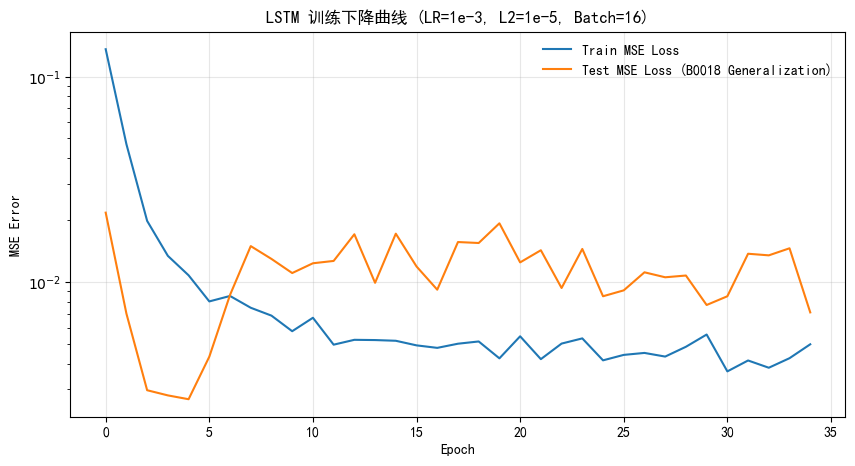

In [16]:
from src.engine.trainer import ModelTrainer
import matplotlib.pyplot as plt
import numpy as np

# 根治中文显示与负号显示问题（设置系统级中文字体）
plt.rcParams['font.sans-serif'] = ['SimHei']  # Windows 常用的黑体
plt.rcParams['axes.unicode_minus'] = False    # 正常显示负号，这行就是解决方块减号的神器

# 【调优3】: 降低正则化的打击力度。学习率稳定，但让L2衰减只惩罚那些极端离谱的权重。
trainer = ModelTrainer(
    model=model, 
    model_type='LSTM',
    lr=1e-3,            # 学习率保持0.001
    weight_decay=1e-5   # 原来1e-4导致惩罚过大造成了“平滑的欠拟合”，现在改回1e-5
)

# 跑个 200 轮 Epoch 体验看看 (并开启 Patience=30 的验证集监控防过拟合)
history = trainer.fit(
    train_loader=train_loader,
    test_loader=test_loader,
    epochs=150,
    patience=30
)

# 绘制训练与验证损失随着 Epoch 推进的下降曲线
plt.figure(figsize=(10, 5))
plt.plot(history['train_loss'], label='Train MSE Loss')
plt.plot(history['test_loss'], label='Test MSE Loss (B0018 Generalization)')
plt.title(f'LSTM 训练下降曲线 (LR=1e-3, L2=1e-5, Batch=16)')
plt.xlabel('Epoch')
plt.ylabel('MSE Error')
plt.legend(frameon=False)
plt.yscale('log') # 使用对数坐标更加清晰地观测小数点后几位微小的震荡

# 【绘图Bug修复】：使用标准的数学模式强行格式化指数负号，避免部分系统字体不支持中横线的问题
from matplotlib.ticker import FuncFormatter
import math
def custom_log_formatter(y, pos):
    if y > 0:
        exponent = int(math.log10(y))
        return f'$10^{{{exponent}}}$'
    return '0'
plt.gca().yaxis.set_major_formatter(FuncFormatter(custom_log_formatter))

plt.grid(alpha=0.3)
plt.show()

### 测试集泛化性能评估：预测寿命轨迹 vs 真实寿命轨迹

在这里，我们将借助上一步更新得到的 `target_scaler` 的**反归一化（Inverse Transform）**能力，将模型在 B0018 盲测集上预测出的毫无维度的 `[0,1]` 标量完美平移回真实的物理 SOH（70% - 100%）。
只有当真实的退化蓝线与我们预测出的红线高精度拟合，并且准确相交在 70% EOL（End of Life）线时，我们才能宣告模型初步成功！

  🧮 B0018 测试盲测性能物理指标报告
 RMSE (均方根误差): 3.6520 %
 MAE  (平均绝对误差): 3.3316 %
 局部极值最大误差: 9.6882 %



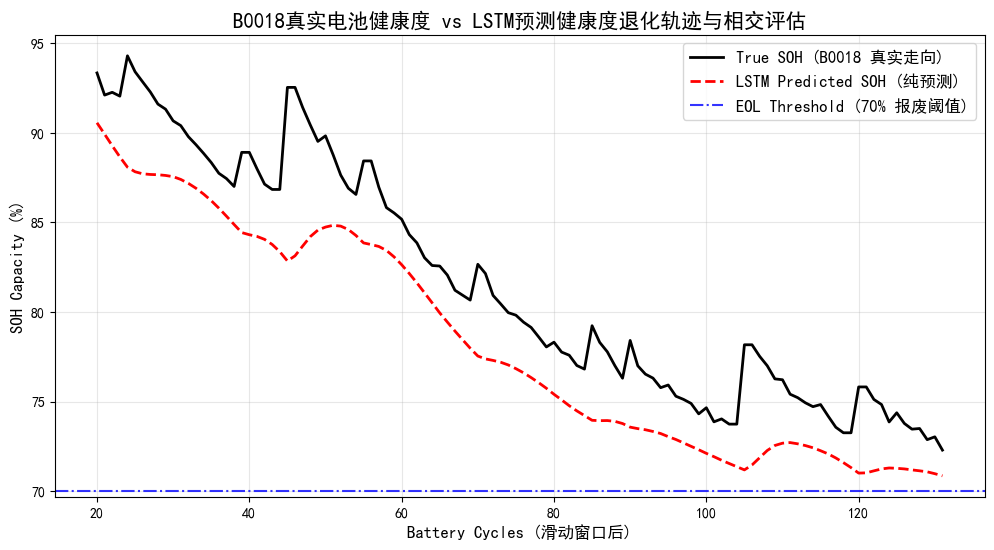

In [17]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 1. 切换至评估模式，收集测试集（B0018）的真实标签和预测值
model.eval()
all_preds = []
all_trues = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        # 放进同样的设备计算（支持GPU）
        device = next(model.parameters()).device
        X_batch = X_batch.to(device)
        
        # 仅利用前20圈提取的特征预测
        preds = model(X_batch).cpu().numpy()
        trues = y_batch.numpy()
        
        all_preds.extend(preds)
        all_trues.extend(trues)

all_preds = np.array(all_preds).reshape(-1, 1)
all_trues = np.array(all_trues).reshape(-1, 1)

# 2. 核心大招：反归一化还原为真实物理量！
# 强制把抽象归一化尺度（0~1）按原方法映射复原成真实的（70% ~ 100% SOH区间）
preds_restored = target_scaler.inverse_transform(all_preds)
trues_restored = target_scaler.inverse_transform(all_trues)

# 3. 计算业务物理指标
rmse = np.sqrt(mean_squared_error(trues_restored, preds_restored))
mae = mean_absolute_error(trues_restored, preds_restored)

print("=" * 45)
print("  🧮 B0018 测试盲测性能物理指标报告")
print("=" * 45)
print(f" RMSE (均方根误差): {rmse:.4f} %")
print(f" MAE  (平均绝对误差): {mae:.4f} %")
print(f" 局部极值最大误差: {np.max(np.abs(trues_restored - preds_restored)):.4f} %\n")

# 4. 寿命曲线对比画图
plt.figure(figsize=(12, 6))

# X轴加上滑动窗口偏移量(20圈)，以真实对应其循环总数横轴
cycle_index = np.arange(20, 20 + len(trues_restored)) 

plt.plot(cycle_index, trues_restored, label='True SOH (B0018 真实走向)', color='black', linewidth=2)
plt.plot(cycle_index, preds_restored, label='LSTM Predicted SOH (纯预测)', color='red', linestyle='--', linewidth=2)

# 画一条 70% 的 EOL (End of Life) 失效基准线
plt.axhline(y=70, color='blue', linestyle='-.', alpha=0.8, label='EOL Threshold (70% 报废阈值)')

plt.title('B0018真实电池健康度 vs LSTM预测健康度退化轨迹与相交评估', fontsize=15)
plt.xlabel('Battery Cycles (滑动窗口后)', fontsize=12)
plt.ylabel('SOH Capacity (%)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.show()

## G1组split训练与评估

本部分用于划分G1组的训练集与测试集，4块电池分别做训练集和测试集

In [18]:
import time
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

g1_batteries = ['B0005', 'B0006', 'B0007', 'B0018']
g1_results = {}

print("=" * 60)
print("🚀 开始 G1 组无重叠交叉验证实验 (Leave-One-Out)")
print("=" * 60)

for test_idx, test_bat in enumerate(g1_batteries):
    # 划分当前折次的训练集和测试集
    train_bats = [b for b in g1_batteries if b != test_bat]
    print(f"\n🌟 [{test_idx+1}/4] 正在运行实验:")
    print(f"   => 测试集 (盲测目标): {test_bat}")
    print(f"   => 训练集 (拟合基准): {train_bats}")
    
    # 1. 动态生成 dataloader, 仅对当前训练集拟合归一化参数，严防数据泄露
    train_loader, test_loader, scaler, target_scaler = data_builder.get_dataloaders(
        train_battery_ids=train_bats,
        test_battery_ids=[test_bat],
        batch_size=16
    )
    
    # 2. 重新初始化全新模型，清空上一次循环的参数记忆
    model_cv = BatteryRULLSTM(
        input_size=len(feature_columns),
        hidden_size=32,    
        num_layers=2,
        dropout=0.05       
    )
    
    # 3. 初始化训练器
    trainer_cv = ModelTrainer(
        model=model_cv, 
        model_type='LSTM',
        lr=1e-3,            
        weight_decay=1e-5   
    )
    
    # 4. 计时与训练模型
    start_time = time.time()
    # verbose=False 可视化保持清爽，仅静默记录history
    history_cv = trainer_cv.fit(train_loader, test_loader, epochs=150, patience=30, verbose=False)
    end_time = time.time()
    
    train_time = end_time - start_time
    print(f"   => ⌛ 训练完成! 停止于第 {len(history_cv['train_loss'])} 轮 (耗时: {train_time:.2f} 秒)")
    
    # 5. 进行推理验证并使用该折次的专属 scaler 予以反归一化还原
    model_cv.eval()
    all_preds, all_trues = [], []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            device = next(model_cv.parameters()).device
            preds = model_cv(X_batch.to(device)).cpu().numpy()
            all_preds.extend(preds)
            all_trues.extend(y_batch.numpy())
            
    all_preds = np.array(all_preds).reshape(-1, 1)
    all_trues = np.array(all_trues).reshape(-1, 1)
    
    preds_restored = target_scaler.inverse_transform(all_preds)
    trues_restored = target_scaler.inverse_transform(all_trues)
    
    # 6. 计算物理指标并归档 (加入 MAPE 指标)
    rmse = np.sqrt(mean_squared_error(trues_restored, preds_restored))
    mae = mean_absolute_error(trues_restored, preds_restored)
    mape = mean_absolute_percentage_error(trues_restored, preds_restored) * 100  # 转换为百分比数值
    
    g1_results[test_bat] = {
        'trues': trues_restored.flatten(),
        'preds': preds_restored.flatten(),
        'rmse': rmse,
        'mae': mae,
        'mape': mape,
        'time': train_time
    }

🚀 开始 G1 组无重叠交叉验证实验 (Leave-One-Out)

🌟 [1/4] 正在运行实验:
   => 测试集 (盲测目标): B0005
   => 训练集 (拟合基准): ['B0006', 'B0007', 'B0018']
🚀 开始在 cuda 上训练 LSTM 模型...
📊 Epoch [1/150] | Train MSE: 0.406600 | Test MSE: 0.132450 | 停止容忍度: 0/30
📊 Epoch [10/150] | Train MSE: 0.009403 | Test MSE: 0.002905 | 停止容忍度: 0/30
📊 Epoch [20/150] | Train MSE: 0.009020 | Test MSE: 0.002116 | 停止容忍度: 1/30
📊 Epoch [30/150] | Train MSE: 0.006178 | Test MSE: 0.002709 | 停止容忍度: 11/30
📊 Epoch [40/150] | Train MSE: 0.007220 | Test MSE: 0.003256 | 停止容忍度: 21/30
📊 Epoch [50/150] | Train MSE: 0.005028 | Test MSE: 0.006395 | 停止容忍度: 9/30
📊 Epoch [60/150] | Train MSE: 0.005033 | Test MSE: 0.003951 | 停止容忍度: 19/30
📊 Epoch [70/150] | Train MSE: 0.005613 | Test MSE: 0.004647 | 停止容忍度: 29/30
⚠️ 在 Epoch 71 触发 Early Stopping (早停)，停止训练防过拟合。
✨ 训练结束。已回滚至最佳验证权重，最优测试集 MSE 为: 0.000836
   => ⌛ 训练完成! 停止于第 71 轮 (耗时: 5.74 秒)

🌟 [2/4] 正在运行实验:
   => 测试集 (盲测目标): B0006
   => 训练集 (拟合基准): ['B0005', 'B0007', 'B0018']
🚀 开始在 cuda 上训练 LSTM 模型...
📊 Epoch [1/150] | Tr


📊 G1组多折交叉验证实验结果汇总表


,测试电池 (Test Set),RMSE (%),MAE (%),MAPE (%),训练耗时 (秒)
0,B0005,4.03530,3.69270,4.3123,5.7400
1,B0006,6.34060,5.96100,8.3803,5.5000
2,B0007,1.98570,1.72220,2.0364,4.6200
3,B0018,5.95620,5.63910,6.8026,2.7100
Average,交叉验证平均 (CV Mean),4.57945,4.25375,5.3829,4.6425


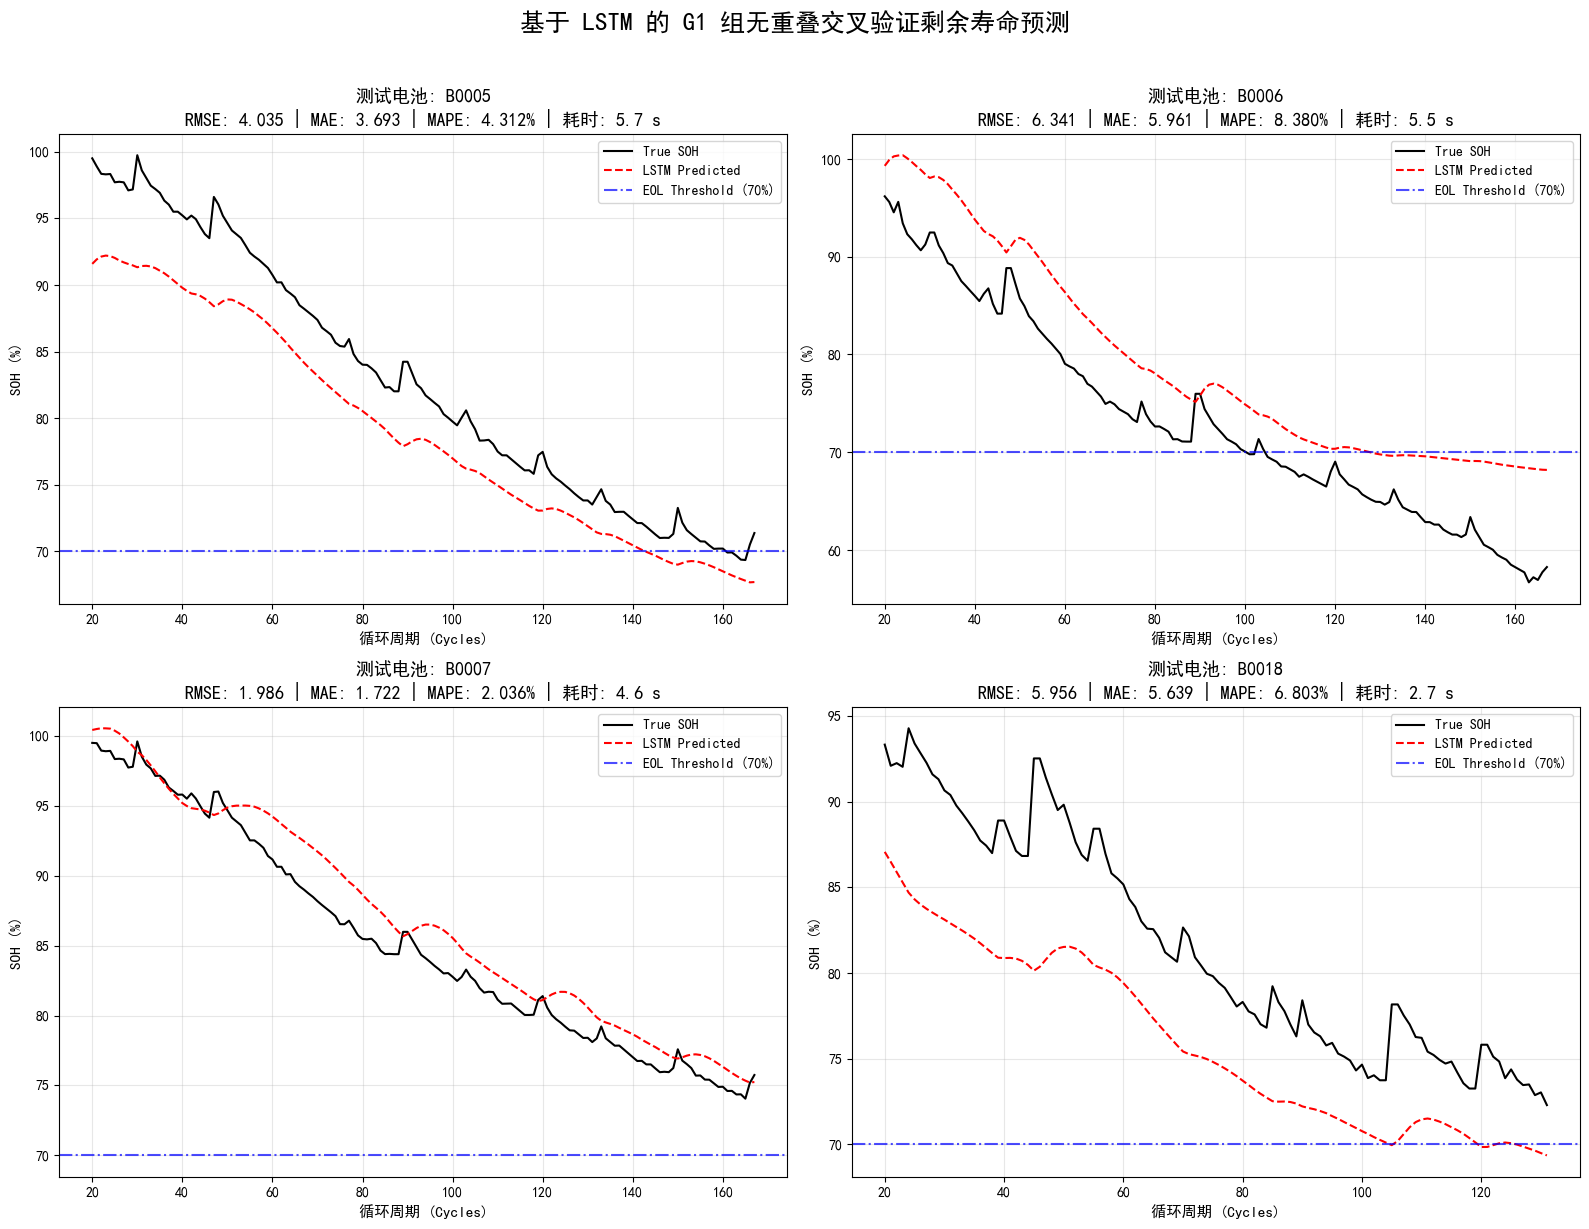

In [19]:
import pandas as pd

# 1. 汇总指标输出到结构化统计表格，便于论文引用 (包含新的 MAPE 指标)
metrics_list = []
for bat, res in g1_results.items():
    metrics_list.append({
        '测试电池 (Test Set)': bat,
        'RMSE (%)': round(res['rmse'], 4),
        'MAE (%)': round(res['mae'], 4),
        'MAPE (%)': round(res['mape'], 4),
        '训练耗时 (秒)': round(res['time'], 2)
    })

df_metrics = pd.DataFrame(metrics_list)
# 计算平均值以体现模型整体泛化能力
df_metrics.loc['Average'] = df_metrics.mean(numeric_only=True)
df_metrics.loc['Average', '测试电池 (Test Set)'] = '交叉验证平均 (CV Mean)'

print("\n" + "=" * 55)
print("📊 G1组多折交叉验证实验结果汇总表")
print("=" * 55)
display(df_metrics)

# 2. 绘制高品质学术 2x2 拟合状态网格图
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, (bat, res) in enumerate(g1_results.items()):
    ax = axes[idx]
    
    # 遵循 20 的滑动窗口偏移
    cycle_index = np.arange(20, 20 + len(res['trues'])) 
    
    ax.plot(cycle_index, res['trues'], label='True SOH', color='black', linewidth=1.5)
    ax.plot(cycle_index, res['preds'], label='LSTM Predicted', color='red', linestyle='--', linewidth=1.5)
    ax.axhline(y=70, color='blue', linestyle='-.', alpha=0.7, label='EOL Threshold (70%)')
    
    title_str = (f"测试电池: {bat}\n"
                 f"RMSE: {res['rmse']:.3f} | MAE: {res['mae']:.3f} | MAPE: {res['mape']:.3f}% | 耗时: {res['time']:.1f} s")
    
    ax.set_title(title_str, fontsize=13, fontweight='bold')
    ax.set_xlabel('循环周期 (Cycles)', fontsize=11)
    ax.set_ylabel('SOH (%)', fontsize=11)
    ax.legend(loc='upper right')
    ax.grid(alpha=0.3)

plt.suptitle('基于 LSTM 的 G1 组无重叠交叉验证剩余寿命预测', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

## G3组的split训练和评估

In [20]:
import time
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

# G3组电池 (不同放电工况，但均为同组分布)
g3_batteries = ['B0029', 'B0030', 'B0031', 'B0032']
g3_results = {}

print("=" * 60)
print("🚀 开始 G3 组无重叠交叉验证实验 (Leave-One-Out)")
print("=" * 60)

for test_idx, test_bat in enumerate(g3_batteries):
    # 划分当前折次的训练集和测试集
    train_bats = [b for b in g3_batteries if b != test_bat]
    print(f"\n🌟 [{test_idx+1}/4] 正在运行 G3 组实验:")
    print(f"   => 测试集 (盲测目标): {test_bat}")
    print(f"   => 训练集 (拟合基准): {train_bats}")
    
    # 1. 动态生成 dataloader, 仅对当前训练集拟合归一化参数，严防数据泄露
    train_loader_g3, test_loader_g3, scaler_g3, target_scaler_g3 = data_builder.get_dataloaders(
        train_battery_ids=train_bats,
        test_battery_ids=[test_bat],
        batch_size=16
    )
    
    # 2. 重新初始化全新模型，清空所有记忆！
    model_g3_cv = BatteryRULLSTM(
        input_size=len(feature_columns),
        hidden_size=32,    
        num_layers=2,
        dropout=0.05       
    )
    
    # 3. 初始化独立的训练器
    trainer_g3_cv = ModelTrainer(
        model=model_g3_cv, 
        model_type='LSTM',
        lr=1e-3,            
        weight_decay=1e-5   
    )
    
    # 4. 计时与独立训练模型
    start_time = time.time()
    # verbose=False 可视化保持清爽
    history_cv_g3 = trainer_g3_cv.fit(train_loader_g3, test_loader_g3, epochs=150, patience=30, verbose=False)
    end_time = time.time()
    
    train_time = end_time - start_time
    print(f"   => ⌛ 训练完成! 停止于第 {len(history_cv_g3['train_loss'])} 轮 (耗时: {train_time:.2f} 秒)")
    
    # 5. 进行推理验证并使用该折次的专属 target_scaler_g3 予以反归一化还原
    model_g3_cv.eval()
    all_preds, all_trues = [], []
    with torch.no_grad():
        for X_batch, y_batch in test_loader_g3:
            device = next(model_g3_cv.parameters()).device
            preds = model_g3_cv(X_batch.to(device)).cpu().numpy()
            all_preds.extend(preds)
            all_trues.extend(y_batch.numpy())
            
    all_preds = np.array(all_preds).reshape(-1, 1)
    all_trues = np.array(all_trues).reshape(-1, 1)
    
    preds_restored = target_scaler_g3.inverse_transform(all_preds)
    trues_restored = target_scaler_g3.inverse_transform(all_trues)
    
    # 6. 计算物理指标并归档，加入 MAPE
    rmse = np.sqrt(mean_squared_error(trues_restored, preds_restored))
    mae = mean_absolute_error(trues_restored, preds_restored)
    mape = mean_absolute_percentage_error(trues_restored, preds_restored) * 100
    
    g3_results[test_bat] = {
        'trues': trues_restored.flatten(),
        'preds': preds_restored.flatten(),
        'rmse': rmse,
        'mae': mae,
        'mape': mape,
        'time': train_time
    }

🚀 开始 G3 组无重叠交叉验证实验 (Leave-One-Out)

🌟 [1/4] 正在运行 G3 组实验:
   => 测试集 (盲测目标): B0029
   => 训练集 (拟合基准): ['B0030', 'B0031', 'B0032']
🚀 开始在 cuda 上训练 LSTM 模型...
📊 Epoch [1/150] | Train MSE: 0.107208 | Test MSE: 0.072333 | 停止容忍度: 0/30
📊 Epoch [10/150] | Train MSE: 0.025432 | Test MSE: 0.017940 | 停止容忍度: 0/30
📊 Epoch [20/150] | Train MSE: 0.006506 | Test MSE: 0.071730 | 停止容忍度: 9/30
📊 Epoch [30/150] | Train MSE: 0.004509 | Test MSE: 0.061992 | 停止容忍度: 19/30
📊 Epoch [40/150] | Train MSE: 0.004308 | Test MSE: 0.050342 | 停止容忍度: 29/30
⚠️ 在 Epoch 41 触发 Early Stopping (早停)，停止训练防过拟合。
✨ 训练结束。已回滚至最佳验证权重，最优测试集 MSE 为: 0.017523
   => ⌛ 训练完成! 停止于第 41 轮 (耗时: 0.74 秒)

🌟 [2/4] 正在运行 G3 组实验:
   => 测试集 (盲测目标): B0030
   => 训练集 (拟合基准): ['B0029', 'B0031', 'B0032']
🚀 开始在 cuda 上训练 LSTM 模型...
📊 Epoch [1/150] | Train MSE: 0.204251 | Test MSE: 0.129886 | 停止容忍度: 0/30
📊 Epoch [10/150] | Train MSE: 0.030785 | Test MSE: 0.023724 | 停止容忍度: 3/30
📊 Epoch [20/150] | Train MSE: 0.026137 | Test MSE: 0.016153 | 停止容忍度: 7/30
📊 Epoch [30/1

### G3绘图
以下是G3组的绘图模块


📊 G3组多折交叉验证实验结果汇总表


,测试电池 (Test Set),RMSE (%),MAE (%),MAPE (%),训练耗时 (秒)
0,B0029,3.3980,3.25360,3.60880,0.74
1,B0030,1.3246,1.09910,1.21110,0.95
2,B0031,1.5843,1.49970,1.60870,0.73
3,B0032,1.7195,1.45140,1.59760,1.54
Average,交叉验证平均 (CV Mean),2.0066,1.82595,2.00655,0.99


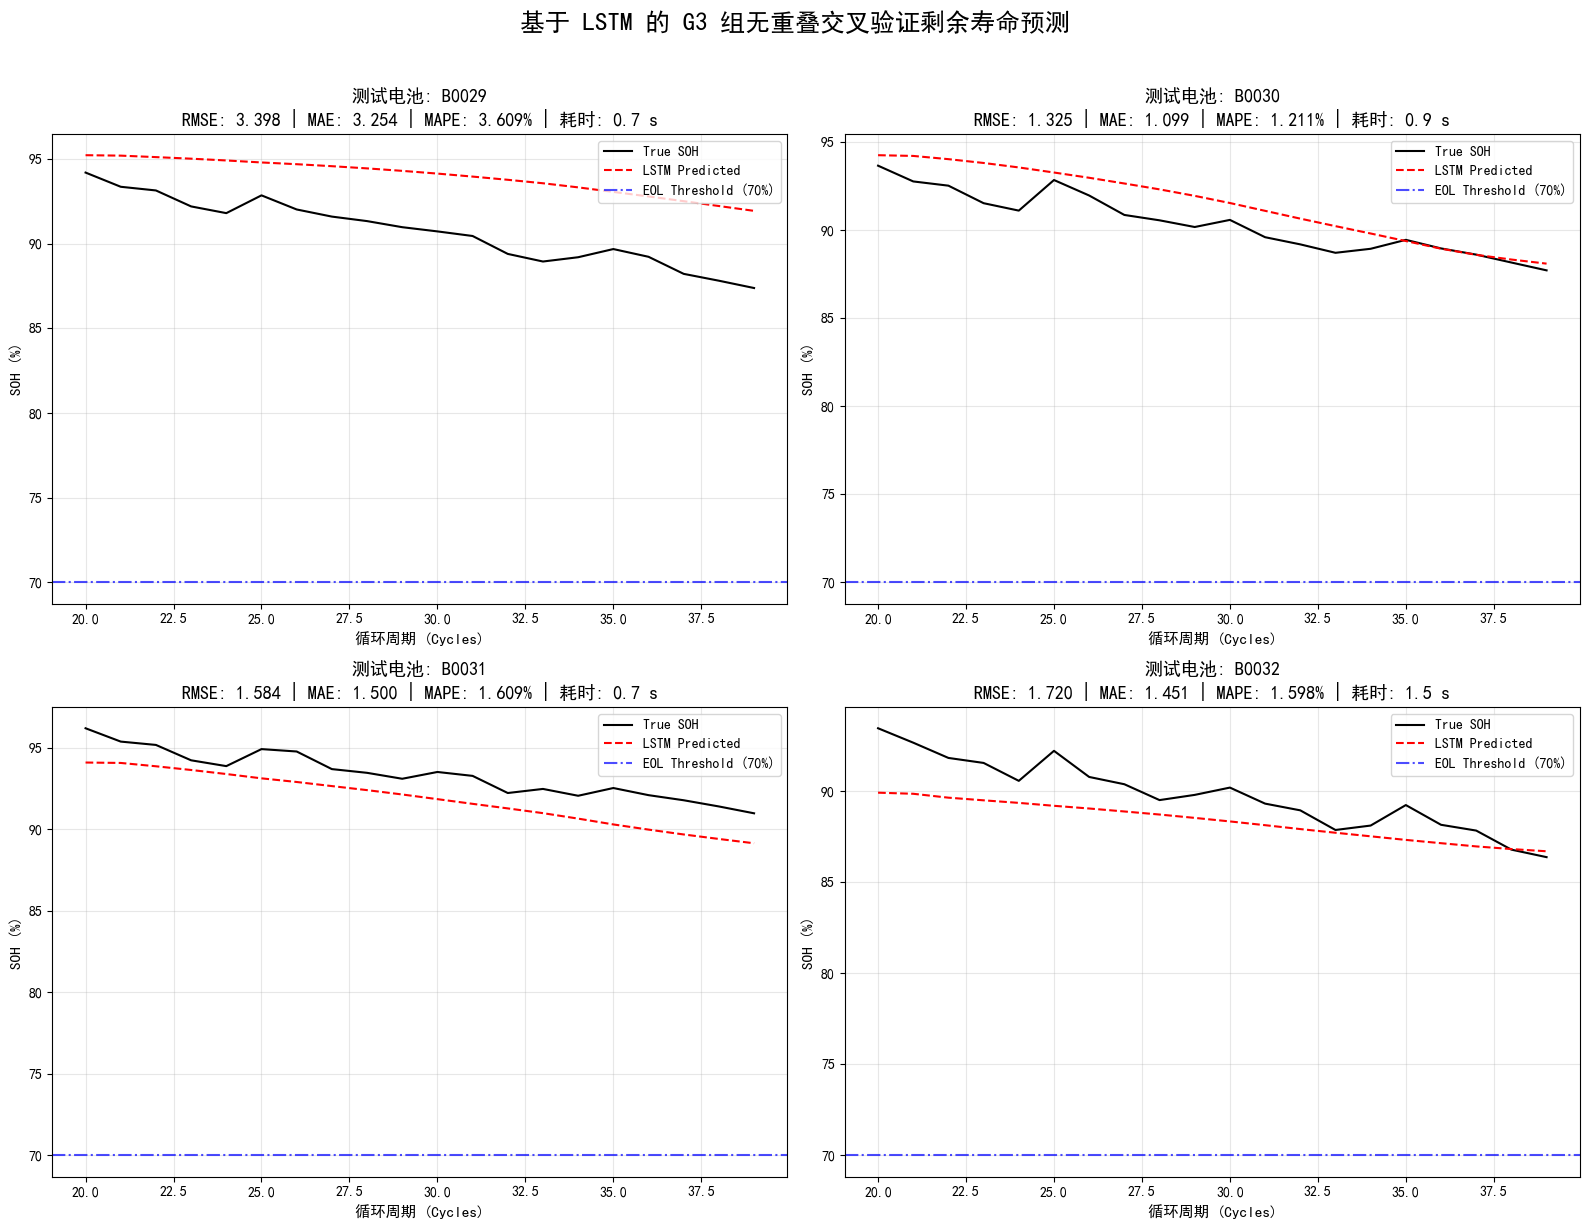

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 汇总指标输出到结构化统计表格，便于论文引用
metrics_list_g3 = []
for bat, res in g3_results.items():
    metrics_list_g3.append({
        '测试电池 (Test Set)': bat,
        'RMSE (%)': round(res['rmse'], 4),
        'MAE (%)': round(res['mae'], 4),
        'MAPE (%)': round(res['mape'], 4),
        '训练耗时 (秒)': round(res['time'], 2)
    })

df_metrics_g3 = pd.DataFrame(metrics_list_g3)
# 计算平均值以体现模型整体泛化能力
df_metrics_g3.loc['Average'] = df_metrics_g3.mean(numeric_only=True)
df_metrics_g3.loc['Average', '测试电池 (Test Set)'] = '交叉验证平均 (CV Mean)'

print("\n" + "=" * 55)
print("📊 G3组多折交叉验证实验结果汇总表")
print("=" * 55)
display(df_metrics_g3)

# 2. 绘制高品质学术 2x2 拟合状态网格图 (G3组)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, (bat, res) in enumerate(g3_results.items()):
    ax = axes[idx]
    
    # 遵循 20 的滑动窗口偏移
    cycle_index = np.arange(20, 20 + len(res['trues'])) 
    
    ax.plot(cycle_index, res['trues'], label='True SOH', color='black', linewidth=1.5)
    ax.plot(cycle_index, res['preds'], label='LSTM Predicted', color='red', linestyle='--', linewidth=1.5)
    
    # 注意，G3的退化阈值如果不同的话，这里假定也是70%，以实际数据为准
    ax.axhline(y=70, color='blue', linestyle='-.', alpha=0.7, label='EOL Threshold (70%)')
    
    title_str = (f"测试电池: {bat}\n"
                 f"RMSE: {res['rmse']:.3f} | MAE: {res['mae']:.3f} | MAPE: {res['mape']:.3f}% | 耗时: {res['time']:.1f} s")
    
    ax.set_title(title_str, fontsize=13, fontweight='bold')
    ax.set_xlabel('循环周期 (Cycles)', fontsize=11)
    ax.set_ylabel('SOH (%)', fontsize=11)
    ax.legend(loc='upper right')
    ax.grid(alpha=0.3)

plt.suptitle('基于 LSTM 的 G3 组无重叠交叉验证剩余寿命预测', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

## G9同工况实验

In [22]:
import time
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import pandas as pd
import matplotlib.pyplot as plt

# G9组电池 (4°C低温恶劣工况，存在异常波动的样本)
g9_batteries = ['B0053', 'B0054', 'B0055', 'B0056']
g9_results = {}

print("=" * 60)
print("❄️ 开始 G9 组无重叠交叉验证实验 (Leave-One-Out)")
print("=" * 60)

for test_idx, test_bat in enumerate(g9_batteries):
    # 划分当前折次的训练集和测试集
    train_bats = [b for b in g9_batteries if b != test_bat]
    print(f"\n🌟 [{test_idx+1}/4] 正在运行 G9 组实验:")
    print(f"   => 测试集 (盲测目标): {test_bat}")
    print(f"   => 训练集 (拟合基准): {train_bats}")
    
    # 1. 动态生成 dataloader
    train_loader_g9, test_loader_g9, scaler_g9, target_scaler_g9 = data_builder.get_dataloaders(
        train_battery_ids=train_bats,
        test_battery_ids=[test_bat],
        batch_size=16
    )
    
    # 2. 重新初始化全新模型，清空记忆
    model_g9_cv = BatteryRULLSTM(
        input_size=len(feature_columns),
        hidden_size=32,    
        num_layers=2,
        dropout=0.05       
    )
    
    # 3. 初始化训练器 (对于波动的低温数据可略微放宽学习率避免无法收敛)
    trainer_g9_cv = ModelTrainer(
        model=model_g9_cv, 
        model_type='LSTM',
        lr=1e-3,            
        weight_decay=1e-5   
    )
    
    # 4. 训练模型
    start_time = time.time()
    history_cv_g9 = trainer_g9_cv.fit(train_loader_g9, test_loader_g9, epochs=150, patience=30, verbose=False)
    end_time = time.time()
    
    train_time = end_time - start_time
    print(f"   => ⌛ 训练完成! 停止于第 {len(history_cv_g9['train_loss'])} 轮 (耗时: {train_time:.2f} 秒)")
    
    # 5. 推理验证并反归一化
    model_g9_cv.eval()
    all_preds, all_trues = [], []
    with torch.no_grad():
        for X_batch, y_batch in test_loader_g9:
            device = next(model_g9_cv.parameters()).device
            preds = model_g9_cv(X_batch.to(device)).cpu().numpy()
            all_preds.extend(preds)
            all_trues.extend(y_batch.numpy())
            
    all_preds = np.array(all_preds).reshape(-1, 1)
    all_trues = np.array(all_trues).reshape(-1, 1)
    
    preds_restored = target_scaler_g9.inverse_transform(all_preds)
    trues_restored = target_scaler_g9.inverse_transform(all_trues)
    
    # 6. 计算评估指标
    rmse = np.sqrt(mean_squared_error(trues_restored, preds_restored))
    mae = mean_absolute_error(trues_restored, preds_restored)
    mape = mean_absolute_percentage_error(trues_restored, preds_restored) * 100
    
    g9_results[test_bat] = {
        'trues': trues_restored.flatten(),
        'preds': preds_restored.flatten(),
        'rmse': rmse,
        'mae': mae,
        'mape': mape,
        'time': train_time
    }

❄️ 开始 G9 组无重叠交叉验证实验 (Leave-One-Out)

🌟 [1/4] 正在运行 G9 组实验:
   => 测试集 (盲测目标): B0053
   => 训练集 (拟合基准): ['B0054', 'B0055', 'B0056']
🚀 开始在 cuda 上训练 LSTM 模型...
📊 Epoch [1/150] | Train MSE: 0.051327 | Test MSE: 0.069187 | 停止容忍度: 0/30
📊 Epoch [10/150] | Train MSE: 0.011250 | Test MSE: 0.076882 | 停止容忍度: 9/30
📊 Epoch [20/150] | Train MSE: 0.008710 | Test MSE: 0.025015 | 停止容忍度: 2/30
📊 Epoch [30/150] | Train MSE: 0.009073 | Test MSE: 0.024328 | 停止容忍度: 2/30
📊 Epoch [40/150] | Train MSE: 0.006759 | Test MSE: 0.014114 | 停止容忍度: 0/30
📊 Epoch [50/150] | Train MSE: 0.006696 | Test MSE: 0.015254 | 停止容忍度: 7/30
📊 Epoch [60/150] | Train MSE: 0.007469 | Test MSE: 0.017710 | 停止容忍度: 17/30
📊 Epoch [70/150] | Train MSE: 0.005747 | Test MSE: 0.013822 | 停止容忍度: 27/30
⚠️ 在 Epoch 73 触发 Early Stopping (早停)，停止训练防过拟合。
✨ 训练结束。已回滚至最佳验证权重，最优测试集 MSE 为: 0.013188
   => ⌛ 训练完成! 停止于第 73 轮 (耗时: 4.25 秒)

🌟 [2/4] 正在运行 G9 组实验:
   => 测试集 (盲测目标): B0054
   => 训练集 (拟合基准): ['B0053', 'B0055', 'B0056']
🚀 开始在 cuda 上训练 LSTM 模型...
📊 Epoch [1/


📊 G9组多折交叉验证实验结果汇总表


,测试电池 (Test Set),RMSE (%),MAE (%),MAPE (%),训练耗时 (秒)
0,B0053,3.326700,2.697800,3.003900,4.2500
1,B0054,6.340000,5.772300,7.442000,2.5600
2,B0055,7.988100,7.411200,9.450800,2.0100
3,B0056,3.165500,2.706000,3.126400,2.8500
Average,交叉验证平均 (CV Mean),5.205075,4.646825,5.755775,2.9175


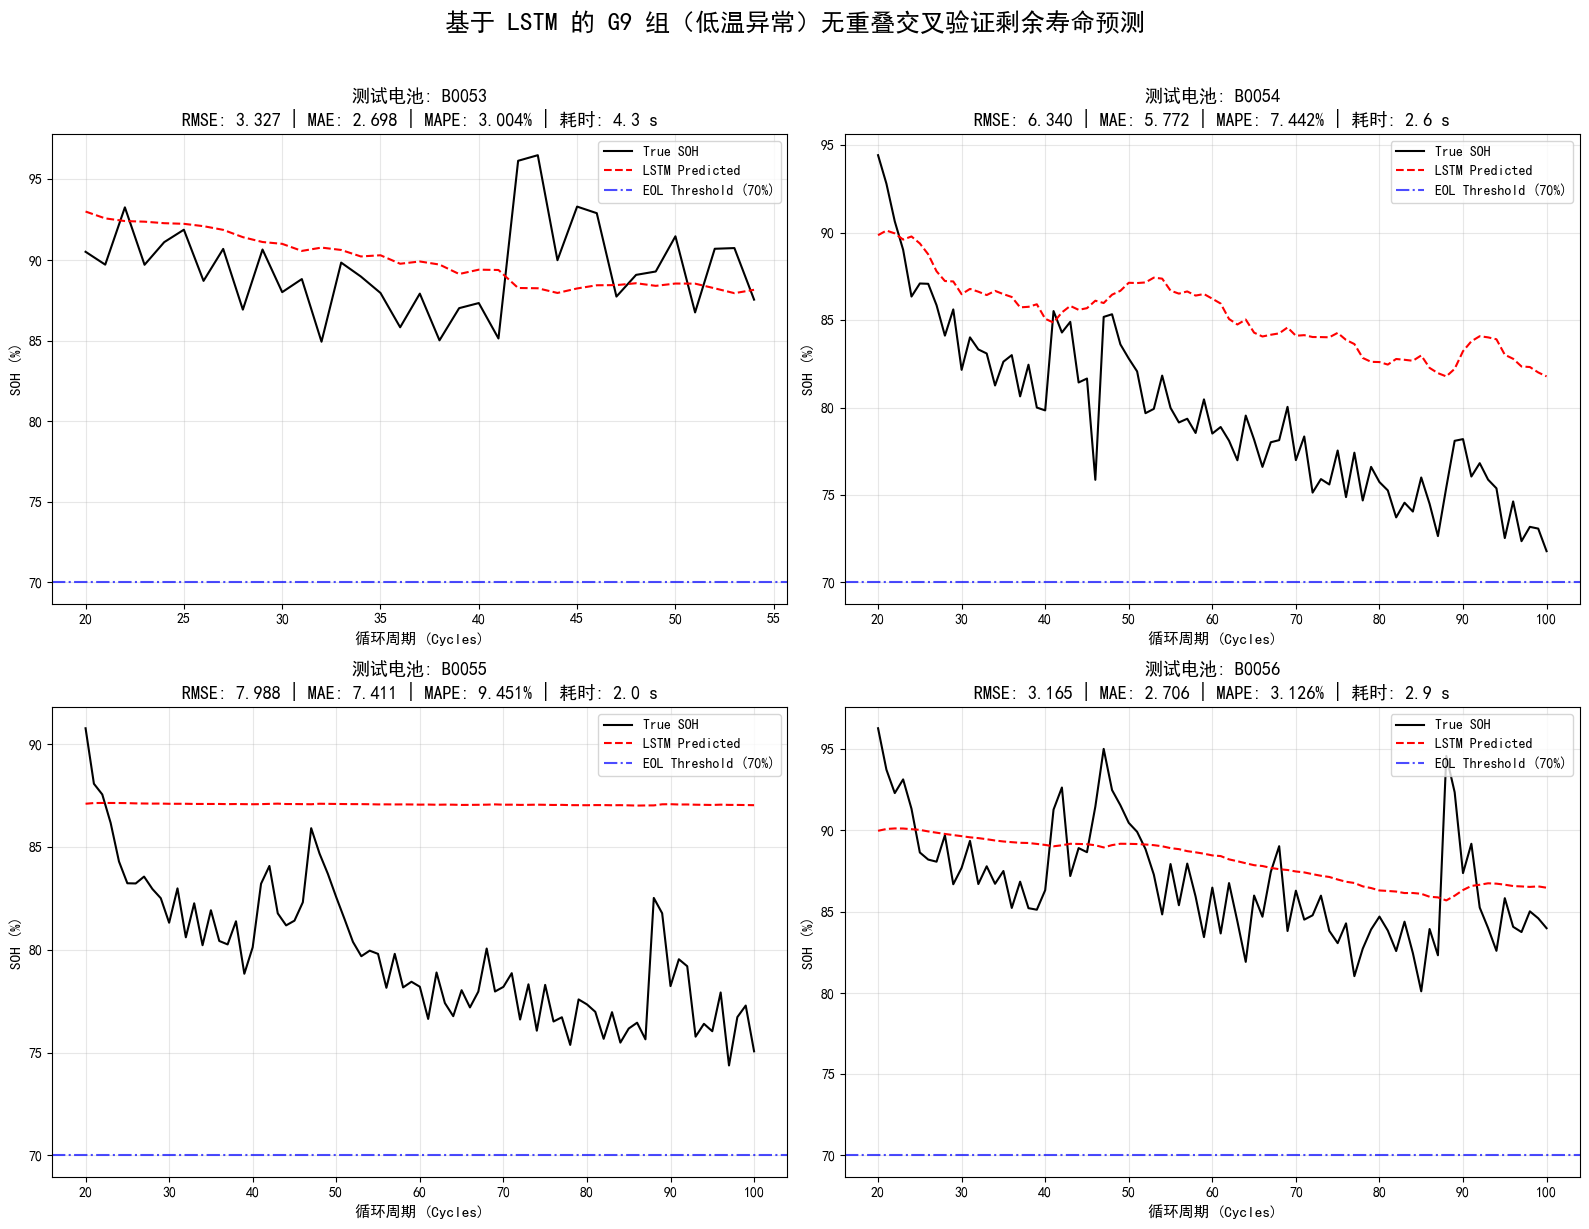

In [23]:
# 1. 汇总指标并输出表格
metrics_list_g9 = []
for bat, res in g9_results.items():
    metrics_list_g9.append({
        '测试电池 (Test Set)': bat,
        'RMSE (%)': round(res['rmse'], 4),
        'MAE (%)': round(res['mae'], 4),
        'MAPE (%)': round(res['mape'], 4),
        '训练耗时 (秒)': round(res['time'], 2)
    })

df_metrics_g9 = pd.DataFrame(metrics_list_g9)
df_metrics_g9.loc['Average'] = df_metrics_g9.mean(numeric_only=True)
df_metrics_g9.loc['Average', '测试电池 (Test Set)'] = '交叉验证平均 (CV Mean)'

print("\n" + "=" * 55)
print("📊 G9组多折交叉验证实验结果汇总表")
print("=" * 55)
display(df_metrics_g9)

# 2. 绘制高品质学术 2x2 拟合状态网格图 (G9组)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, (bat, res) in enumerate(g9_results.items()):
    ax = axes[idx]
    
    # 遵循 20 的滑动窗口偏移
    cycle_index = np.arange(20, 20 + len(res['trues'])) 
    
    ax.plot(cycle_index, res['trues'], label='True SOH', color='black', linewidth=1.5)
    ax.plot(cycle_index, res['preds'], label='LSTM Predicted', color='red', linestyle='--', linewidth=1.5)
    
    # 低温组可能有提前失效标准，此处默认仍使用70%供对比参考
    ax.axhline(y=70, color='blue', linestyle='-.', alpha=0.7, label='EOL Threshold (70%)')
    
    title_str = (f"测试电池: {bat}\n"
                 f"RMSE: {res['rmse']:.3f} | MAE: {res['mae']:.3f} | MAPE: {res['mape']:.3f}% | 耗时: {res['time']:.1f} s")
    
    ax.set_title(title_str, fontsize=13, fontweight='bold')
    ax.set_xlabel('循环周期 (Cycles)', fontsize=11)
    ax.set_ylabel('SOH (%)', fontsize=11)
    ax.legend(loc='upper right')
    ax.grid(alpha=0.3)

plt.suptitle('基于 LSTM 的 G9 组（低温异常）无重叠交叉验证剩余寿命预测', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

## 留一电池实验

### 室温组测试实验

本部分选择室温组的某一块电池作为测试集，检验模型的跨工况的泛化能力

🌍 跨工况全局混合泛化能力测试 - 室温测试集 (B0018)
🎯 总计参与电池数: 12 块
📦 作为拟合基准的大规模混合训练集 (11 块):
   ['B0005', 'B0006', 'B0007', 'B0029', 'B0030', 'B0031', 'B0032', 'B0053', 'B0054', 'B0055', 'B0056']
🔬 作为盲测的电池: B0018

正在进行万批次级的多工况数据融合训练，请稍候...
🚀 开始在 cuda 上训练 LSTM 模型...
📊 Epoch [1/150] | Train MSE: 0.113563 | Test MSE: 0.029131 | 停止容忍度: 0/30
📊 Epoch [10/150] | Train MSE: 0.012682 | Test MSE: 0.002255 | 停止容忍度: 0/30
📊 Epoch [20/150] | Train MSE: 0.009363 | Test MSE: 0.002270 | 停止容忍度: 1/30
📊 Epoch [30/150] | Train MSE: 0.008444 | Test MSE: 0.002086 | 停止容忍度: 1/30
📊 Epoch [40/150] | Train MSE: 0.006986 | Test MSE: 0.002227 | 停止容忍度: 11/30
📊 Epoch [50/150] | Train MSE: 0.005410 | Test MSE: 0.001759 | 停止容忍度: 0/30
📊 Epoch [60/150] | Train MSE: 0.004916 | Test MSE: 0.003794 | 停止容忍度: 3/30
📊 Epoch [70/150] | Train MSE: 0.004487 | Test MSE: 0.004864 | 停止容忍度: 13/30
📊 Epoch [80/150] | Train MSE: 0.003870 | Test MSE: 0.001618 | 停止容忍度: 23/30
⚠️ 在 Epoch 87 触发 Early Stopping (早停)，停止训练防过拟合。
✨ 训练结束。已回滚至最佳验证权重，最优测试集 MSE 为: 0.00145

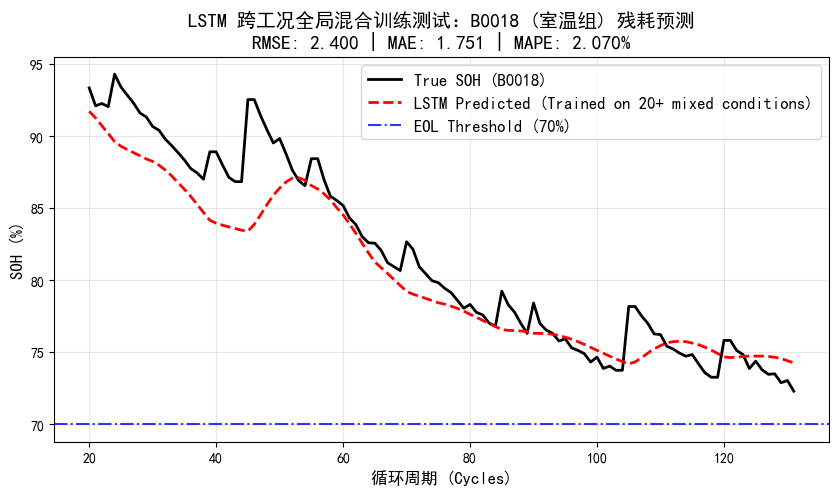

In [24]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import torch

# 1. 动态获取 data/features/by_battery 目录下的全部电池 ID
all_files = os.listdir(FEATURE_DIR)
all_batteries = sorted(list(set([f.split('_')[0] for f in all_files if f.endswith('_features.csv')])))

# 2. 选定室温组（G1组）的 B0018 作为全局泛化盲测的测试集
test_battery_global = 'B0018'
train_batteries_global = [b for b in all_batteries if b != test_battery_global]

print("=" * 60)
print("🌍 跨工况全局混合泛化能力测试 - 室温测试集 (B0018)")
print("=" * 60)
print(f"🎯 总计参与电池数: {len(all_batteries)} 块")
print(f"📦 作为拟合基准的大规模混合训练集 ({len(train_batteries_global)} 块):\n   {train_batteries_global}")
print(f"🔬 作为盲测的电池: {test_battery_global}")

# 3. 数据装配 (混入了几十块各种工况的电池，稍微扩大 batch_size 到 32 以平衡梯度下降方向)
train_loader_gl, test_loader_gl, scaler_gl, target_scaler_gl = data_builder.get_dataloaders(
    train_battery_ids=train_batteries_global,
    test_battery_ids=[test_battery_global],
    batch_size=32
)

# 4. 初始化全新的 LSTM 模型
model_global = BatteryRULLSTM(
    input_size=len(feature_columns),
    hidden_size=32,    
    num_layers=2,
    dropout=0.05
)

# 5. 训练模型
trainer_global = ModelTrainer(
    model=model_global, 
    model_type='LSTM',
    lr=1e-3,            
    weight_decay=1e-5   
)

start_time = time.time()
print("\n正在进行万批次级的多工况数据融合训练，请稍候...")
history_global = trainer_global.fit(train_loader_gl, test_loader_gl, epochs=150, patience=30, verbose=False)
print(f"✅ [全局训练完成] 共经历 {len(history_global['train_loss'])} 轮，耗时 {time.time() - start_time:.2f} 秒")

# 6. 推理与反归一化还原
model_global.eval()
all_preds_gl, all_trues_gl = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader_gl:
        dev = next(model_global.parameters()).device
        preds = model_global(X_batch.to(dev)).cpu().numpy()
        all_preds_gl.extend(preds)
        all_trues_gl.extend(y_batch.numpy())
        
preds_restored_gl = target_scaler_gl.inverse_transform(np.array(all_preds_gl).reshape(-1, 1)).flatten()
trues_restored_gl = target_scaler_gl.inverse_transform(np.array(all_trues_gl).reshape(-1, 1)).flatten()

# 7. 计算业务指标
rmse_g = np.sqrt(mean_squared_error(trues_restored_gl, preds_restored_gl))
mae_g = mean_absolute_error(trues_restored_gl, preds_restored_gl)
mape_g = mean_absolute_percentage_error(trues_restored_gl, preds_restored_gl) * 100

print(f"\n📊 跨工况预测 {test_battery_global} 结果:")
print(f"   RMSE: {rmse_g:.4f} % | MAE: {mae_g:.4f} % | MAPE: {mape_g:.4f} %\n")

# 8. 绘制验证图
plt.figure(figsize=(10, 5))
cycle_index = np.arange(20, 20 + len(trues_restored_gl)) 
plt.plot(cycle_index, trues_restored_gl, label='True SOH (B0018)', color='black', linewidth=2)
plt.plot(cycle_index, preds_restored_gl, label='LSTM Predicted (Trained on 20+ mixed conditions)', color='red', linestyle='--', linewidth=2)
plt.axhline(y=70, color='blue', linestyle='-.', alpha=0.8, label='EOL Threshold (70%)')

plt.title(f'LSTM 跨工况全局混合训练测试：{test_battery_global} (室温组) 残耗预测\nRMSE: {rmse_g:.3f} | MAE: {mae_g:.3f} | MAPE: {mape_g:.3f}%', fontsize=14)
plt.xlabel('循环周期 (Cycles)', fontsize=12)
plt.ylabel('SOH (%)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.show()

### 高温组留一电池实验

本部分从高温组G3选择一块电池作为测试集。

🌍 跨工况全局混合泛化能力测试 - 高温测试集 (B0029)
🎯 总计参与电池数: 12 块
📦 作为拟合基准的大规模混合训练集 (11 块):
   ['B0005', 'B0006', 'B0007', 'B0018', 'B0030', 'B0031', 'B0032', 'B0053', 'B0054', 'B0055', 'B0056']
🔬 作为盲测的电池: B0029

正在进行万批次级的多工况数据融合训练，请稍候...
🚀 开始在 cuda 上训练 LSTM 模型...
📊 Epoch [1/150] | Train MSE: 0.094114 | Test MSE: 0.014384 | 停止容忍度: 0/30
📊 Epoch [10/150] | Train MSE: 0.008978 | Test MSE: 0.001708 | 停止容忍度: 3/30
📊 Epoch [20/150] | Train MSE: 0.007173 | Test MSE: 0.004099 | 停止容忍度: 13/30
📊 Epoch [30/150] | Train MSE: 0.006334 | Test MSE: 0.004175 | 停止容忍度: 3/30
📊 Epoch [40/150] | Train MSE: 0.004980 | Test MSE: 0.005035 | 停止容忍度: 13/30
📊 Epoch [50/150] | Train MSE: 0.004575 | Test MSE: 0.002684 | 停止容忍度: 23/30
⚠️ 在 Epoch 57 触发 Early Stopping (早停)，停止训练防过拟合。
✨ 训练结束。已回滚至最佳验证权重，最优测试集 MSE 为: 0.000378
✅ [全局训练完成] 共经历 57 轮，耗时 4.69 秒

📊 跨工况预测 B0029 结果:
   RMSE: 2.9361 % | MAE: 2.5076 % | MAPE: 2.7998 %



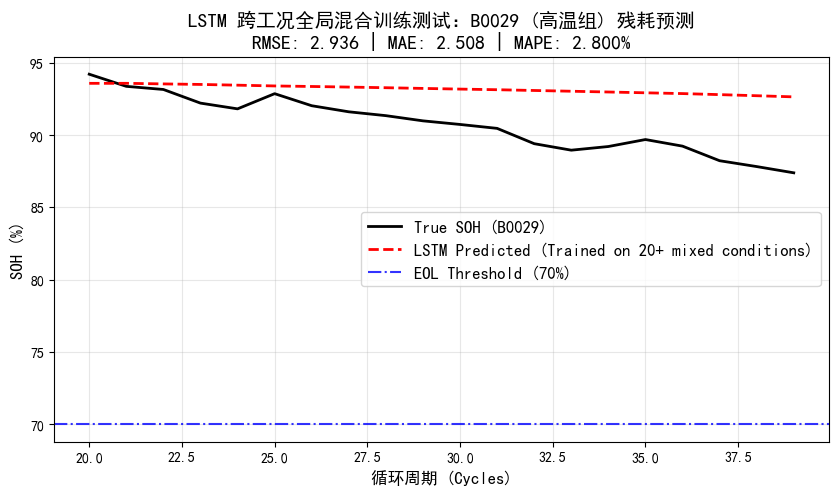

In [25]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import torch

# 1. 选定高温组（G3组）的 B0029 作为全局泛化盲测的测试集
test_battery_global_g3 = 'B0029'
train_batteries_global_g3 = [b for b in all_batteries if b != test_battery_global_g3]

print("=" * 60)
print("🌍 跨工况全局混合泛化能力测试 - 高温测试集 (B0029)")
print("=" * 60)
print(f"🎯 总计参与电池数: {len(all_batteries)} 块")
print(f"📦 作为拟合基准的大规模混合训练集 ({len(train_batteries_global_g3)} 块):\n   {train_batteries_global_g3}")
print(f"🔬 作为盲测的电池: {test_battery_global_g3}")

# 2. 数据装配，使用之前得到的 data_builder
train_loader_g3_gl, test_loader_g3_gl, scaler_g3_gl, target_scaler_g3_gl = data_builder.get_dataloaders(
    train_battery_ids=train_batteries_global_g3,
    test_battery_ids=[test_battery_global_g3],
    batch_size=32
)

# 3. 初始化全新的 LSTM 模型
model_global_g3 = BatteryRULLSTM(
    input_size=len(feature_columns),
    hidden_size=32,    
    num_layers=2,
    dropout=0.05
)

# 4. 训练模型
trainer_global_g3 = ModelTrainer(
    model=model_global_g3, 
    model_type='LSTM',
    lr=1e-3,            
    weight_decay=1e-5   
)

start_time = time.time()
print("\n正在进行万批次级的多工况数据融合训练，请稍候...")
history_global_g3 = trainer_global_g3.fit(train_loader_g3_gl, test_loader_g3_gl, epochs=150, patience=30, verbose=False)
print(f"✅ [全局训练完成] 共经历 {len(history_global_g3['train_loss'])} 轮，耗时 {time.time() - start_time:.2f} 秒")

# 5. 推理与反归一化还原
model_global_g3.eval()
all_preds_g3_gl, all_trues_g3_gl = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader_g3_gl:
        dev = next(model_global_g3.parameters()).device
        preds = model_global_g3(X_batch.to(dev)).cpu().numpy()
        all_preds_g3_gl.extend(preds)
        all_trues_g3_gl.extend(y_batch.numpy())
        
preds_restored_g3_gl = target_scaler_g3_gl.inverse_transform(np.array(all_preds_g3_gl).reshape(-1, 1)).flatten()
trues_restored_g3_gl = target_scaler_g3_gl.inverse_transform(np.array(all_trues_g3_gl).reshape(-1, 1)).flatten()

# 6. 计算业务指标
rmse_g3_g = np.sqrt(mean_squared_error(trues_restored_g3_gl, preds_restored_g3_gl))
mae_g3_g = mean_absolute_error(trues_restored_g3_gl, preds_restored_g3_gl)
mape_g3_g = mean_absolute_percentage_error(trues_restored_g3_gl, preds_restored_g3_gl) * 100

print(f"\n📊 跨工况预测 {test_battery_global_g3} 结果:")
print(f"   RMSE: {rmse_g3_g:.4f} % | MAE: {mae_g3_g:.4f} % | MAPE: {mape_g3_g:.4f} %\n")

# 7. 绘制验证图
plt.figure(figsize=(10, 5))
cycle_index_g3 = np.arange(20, 20 + len(trues_restored_g3_gl)) 
plt.plot(cycle_index_g3, trues_restored_g3_gl, label=f'True SOH ({test_battery_global_g3})', color='black', linewidth=2)
plt.plot(cycle_index_g3, preds_restored_g3_gl, label='LSTM Predicted (Trained on 20+ mixed conditions)', color='red', linestyle='--', linewidth=2)
plt.axhline(y=70, color='blue', linestyle='-.', alpha=0.8, label='EOL Threshold (70%)')

plt.title(f'LSTM 跨工况全局混合训练测试：{test_battery_global_g3} (高温组) 残耗预测\nRMSE: {rmse_g3_g:.3f} | MAE: {mae_g3_g:.3f} | MAPE: {mape_g3_g:.3f}%', fontsize=14)
plt.xlabel('循环周期 (Cycles)', fontsize=12)
plt.ylabel('SOH (%)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.show()

### G9组电池留一实验

🌍 跨工况全局混合泛化能力测试 - 低温异常测试集 (B0053)
🎯 总计参与电池数: 12 块
📦 作为拟合基准的大规模混合训练集 (11 块):
   ['B0005', 'B0006', 'B0007', 'B0018', 'B0029', 'B0030', 'B0031', 'B0032', 'B0054', 'B0055', 'B0056']
🔬 作为盲测的电池: B0053

正在进行万批次级的多工况数据融合训练，请稍候...
🚀 开始在 cuda 上训练 LSTM 模型...
📊 Epoch [1/150] | Train MSE: 0.190502 | Test MSE: 0.046008 | 停止容忍度: 0/30
📊 Epoch [10/150] | Train MSE: 0.010101 | Test MSE: 0.024189 | 停止容忍度: 2/30
📊 Epoch [20/150] | Train MSE: 0.007681 | Test MSE: 0.012686 | 停止容忍度: 0/30
📊 Epoch [30/150] | Train MSE: 0.006475 | Test MSE: 0.011760 | 停止容忍度: 7/30
📊 Epoch [40/150] | Train MSE: 0.006055 | Test MSE: 0.010974 | 停止容忍度: 8/30
📊 Epoch [50/150] | Train MSE: 0.005331 | Test MSE: 0.005456 | 停止容忍度: 3/30
📊 Epoch [60/150] | Train MSE: 0.004505 | Test MSE: 0.005804 | 停止容忍度: 2/30
📊 Epoch [70/150] | Train MSE: 0.003561 | Test MSE: 0.004250 | 停止容忍度: 12/30
📊 Epoch [80/150] | Train MSE: 0.003749 | Test MSE: 0.005636 | 停止容忍度: 22/30
⚠️ 在 Epoch 88 触发 Early Stopping (早停)，停止训练防过拟合。
✨ 训练结束。已回滚至最佳验证权重，最优测试集 MSE 为: 0.0042

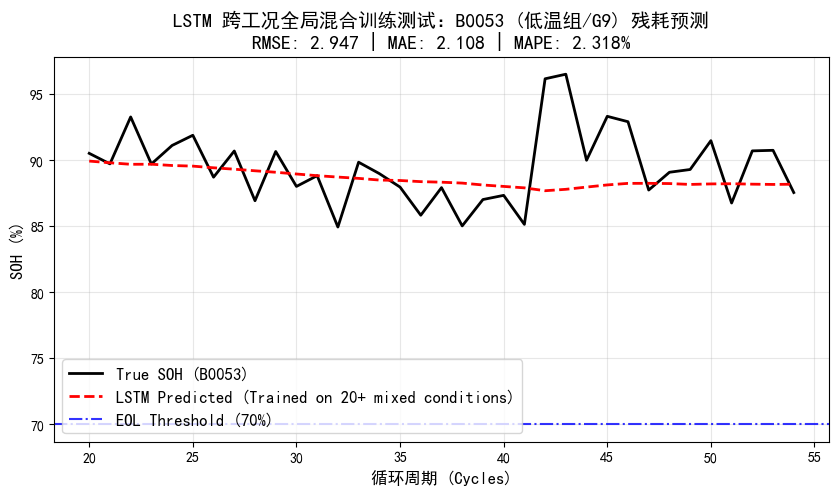

In [26]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import torch

# 1. 选定低温恶劣工况组（G9组）的 B0053 作为全局泛化盲测的测试集
test_battery_global_g9 = 'B0053'
train_batteries_global_g9 = [b for b in all_batteries if b != test_battery_global_g9]

print("=" * 60)
print("🌍 跨工况全局混合泛化能力测试 - 低温异常测试集 (B0053)")
print("=" * 60)
print(f"🎯 总计参与电池数: {len(all_batteries)} 块")
print(f"📦 作为拟合基准的大规模混合训练集 ({len(train_batteries_global_g9)} 块):\n   {train_batteries_global_g9}")
print(f"🔬 作为盲测的电池: {test_battery_global_g9}")

# 2. 数据装配
train_loader_g9_gl, test_loader_g9_gl, scaler_g9_gl, target_scaler_g9_gl = data_builder.get_dataloaders(
    train_battery_ids=train_batteries_global_g9,
    test_battery_ids=[test_battery_global_g9],
    batch_size=32
)

# 3. 初始化全新的 LSTM 模型
model_global_g9 = BatteryRULLSTM(
    input_size=len(feature_columns),
    hidden_size=32,    
    num_layers=2,
    dropout=0.05
)

# 4. 训练模型
trainer_global_g9 = ModelTrainer(
    model=model_global_g9, 
    model_type='LSTM',
    lr=1e-3,            
    weight_decay=1e-5   
)

start_time = time.time()
print("\n正在进行万批次级的多工况数据融合训练，请稍候...")
history_global_g9 = trainer_global_g9.fit(train_loader_g9_gl, test_loader_g9_gl, epochs=150, patience=30, verbose=False)
print(f"✅ [全局训练完成] 共经历 {len(history_global_g9['train_loss'])} 轮，耗时 {time.time() - start_time:.2f} 秒")

# 5. 推理与反归一化还原
model_global_g9.eval()
all_preds_g9_gl, all_trues_g9_gl = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader_g9_gl:
        dev = next(model_global_g9.parameters()).device
        preds = model_global_g9(X_batch.to(dev)).cpu().numpy()
        all_preds_g9_gl.extend(preds)
        all_trues_g9_gl.extend(y_batch.numpy())
        
preds_restored_g9_gl = target_scaler_g9_gl.inverse_transform(np.array(all_preds_g9_gl).reshape(-1, 1)).flatten()
trues_restored_g9_gl = target_scaler_g9_gl.inverse_transform(np.array(all_trues_g9_gl).reshape(-1, 1)).flatten()

# 6. 计算业务指标
rmse_g9_g = np.sqrt(mean_squared_error(trues_restored_g9_gl, preds_restored_g9_gl))
mae_g9_g = mean_absolute_error(trues_restored_g9_gl, preds_restored_g9_gl)
mape_g9_g = mean_absolute_percentage_error(trues_restored_g9_gl, preds_restored_g9_gl) * 100

print(f"\n📊 跨工况预测 {test_battery_global_g9} 结果:")
print(f"   RMSE: {rmse_g9_g:.4f} % | MAE: {mae_g9_g:.4f} % | MAPE: {mape_g9_g:.4f} %\n")

# 7. 绘制验证图
plt.figure(figsize=(10, 5))
cycle_index_g9 = np.arange(20, 20 + len(trues_restored_g9_gl)) 
plt.plot(cycle_index_g9, trues_restored_g9_gl, label=f'True SOH ({test_battery_global_g9})', color='black', linewidth=2)
plt.plot(cycle_index_g9, preds_restored_g9_gl, label='LSTM Predicted (Trained on 20+ mixed conditions)', color='red', linestyle='--', linewidth=2)
plt.axhline(y=70, color='blue', linestyle='-.', alpha=0.8, label='EOL Threshold (70%)')

plt.title(f'LSTM 跨工况全局混合训练测试：{test_battery_global_g9} (低温组/G9) 残耗预测\nRMSE: {rmse_g9_g:.3f} | MAE: {mae_g9_g:.3f} | MAPE: {mape_g9_g:.3f}%', fontsize=14)
plt.xlabel('循环周期 (Cycles)', fontsize=12)
plt.ylabel('SOH (%)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.show()

### 留一电池实验结果汇总图

将上述三个跨工况盲测结果进行整合对比。

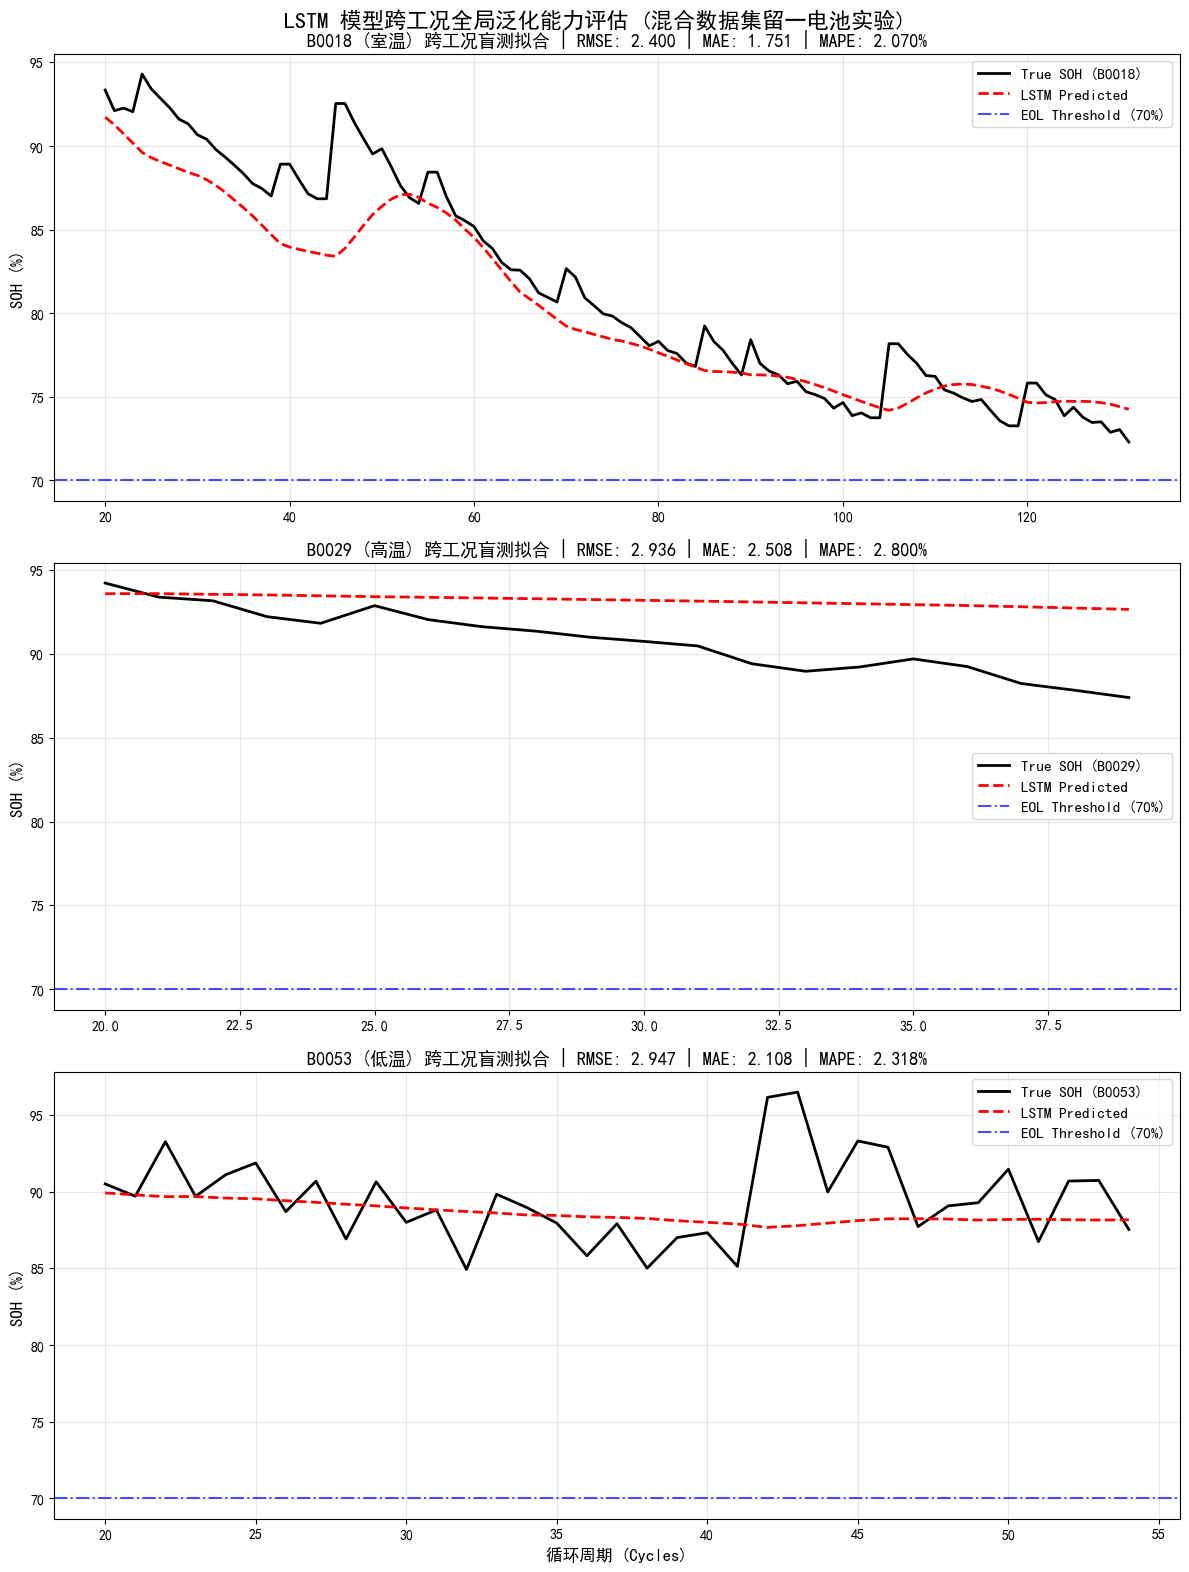

In [27]:
import matplotlib.pyplot as plt
import numpy as np

# 创建 3x1 的纵向对比大图
fig, axes = plt.subplots(3, 1, figsize=(12, 16))

# -----------------
# 1. B0018 (室温组 / G1)
# -----------------
cycle_index_g1 = np.arange(20, 20 + len(trues_restored_gl))
axes[0].plot(cycle_index_g1, trues_restored_gl, label='True SOH (B0018)', color='black', linewidth=2)
axes[0].plot(cycle_index_g1, preds_restored_gl, label='LSTM Predicted', color='red', linestyle='--', linewidth=2)
axes[0].axhline(y=70, color='blue', linestyle='-.', alpha=0.7, label='EOL Threshold (70%)')
axes[0].set_title(f'B0018 (室温) 跨工况盲测拟合 | RMSE: {rmse_g:.3f} | MAE: {mae_g:.3f} | MAPE: {mape_g:.3f}%', fontsize=13)
axes[0].set_ylabel('SOH (%)', fontsize=12)
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)

# -----------------
# 2. B0029 (高温组 / G3)
# -----------------
cycle_index_g3 = np.arange(20, 20 + len(trues_restored_g3_gl))
axes[1].plot(cycle_index_g3, trues_restored_g3_gl, label='True SOH (B0029)', color='black', linewidth=2)
axes[1].plot(cycle_index_g3, preds_restored_g3_gl, label='LSTM Predicted', color='red', linestyle='--', linewidth=2)
axes[1].axhline(y=70, color='blue', linestyle='-.', alpha=0.7, label='EOL Threshold (70%)')
axes[1].set_title(f'B0029 (高温) 跨工况盲测拟合 | RMSE: {rmse_g3_g:.3f} | MAE: {mae_g3_g:.3f} | MAPE: {mape_g3_g:.3f}%', fontsize=13)
axes[1].set_ylabel('SOH (%)', fontsize=12)
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)

# -----------------
# 3. B0053 (低温异常组 / G9)
# -----------------
cycle_index_g9 = np.arange(20, 20 + len(trues_restored_g9_gl))
axes[2].plot(cycle_index_g9, trues_restored_g9_gl, label='True SOH (B0053)', color='black', linewidth=2)
axes[2].plot(cycle_index_g9, preds_restored_g9_gl, label='LSTM Predicted', color='red', linestyle='--', linewidth=2)
axes[2].axhline(y=70, color='blue', linestyle='-.', alpha=0.7, label='EOL Threshold (70%)')
axes[2].set_title(f'B0053 (低温) 跨工况盲测拟合 | RMSE: {rmse_g9_g:.3f} | MAE: {mae_g9_g:.3f} | MAPE: {mape_g9_g:.3f}%', fontsize=13)
axes[2].set_xlabel('循环周期 (Cycles)', fontsize=12)
axes[2].set_ylabel('SOH (%)', fontsize=12)
axes[2].legend(fontsize=11)
axes[2].grid(alpha=0.3)

# 整体标题排版优化
plt.suptitle('LSTM 模型跨工况全局泛化能力评估 (混合数据集留一电池实验)', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()